In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

### What Are Training Dynamics?

**Training dynamics** is about understanding and controlling how your neural network learns.

Think of it like learning to drive:

Dynamics = How you adjust: speed, steering, braking, acceleration


| Question | Parameter |
|----------|-----------|
| How fast should you go? | Learning Rate |
| How many practice sessions? | Epochs |
| How big should your practice batches be? | Batch Size |
| How to avoid crashing? | Overfitting prevention |


In [2]:
# MNIST loading
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = torchvision.datasets.MNIST(
    root='./data', train=True, download=True, transform=transform
)
test_dataset = torchvision.datasets.MNIST(
    root='./data', train=False, download=True, transform=transform
)

In [3]:
class SimpleMNIST(nn.Module):
    def __init__(self):
        super(SimpleMNIST, self).__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28*28, 128)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(128, 10)
    
    def forward(self, x):
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

Training with different learning rates...

  Learning Rate = 0.001
    Final Test Accuracy: 29.20%

  Learning Rate = 0.01
    Final Test Accuracy: 77.40%

  Learning Rate = 0.1
    Final Test Accuracy: 85.60%

  Learning Rate = 1.0
    Final Test Accuracy: 8.60%


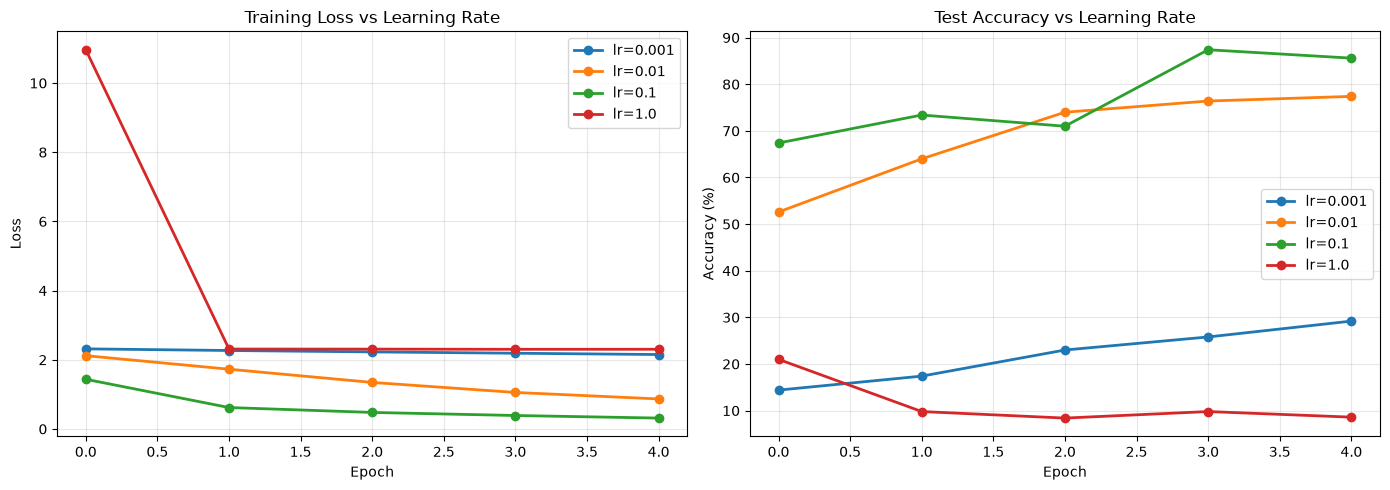


LEARNING RATE INSIGHTS:

• lr = 0.001: Too slow (barely learns)
• lr = 0.01:  Good balance (steady improvement)
• lr = 0.1:   Fast learning, may overshoot
• lr = 1.0:   Too fast (unstable, diverges)

Best learning rate for this task: ~0.01-0.1
Rule of thumb: Start with 0.01 and adjust



In [4]:
print("\n" + "="*60)
print("EFFECT OF LEARNING RATE")
print("="*60)

def train_with_lr(lr, epochs=5):
    """Train model with given learning rate"""
    model = SimpleMNIST()
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=lr)
    
    # Use subset for speed
    train_loader = torch.utils.data.DataLoader(
        torch.utils.data.Subset(train_dataset, range(3000)),
        batch_size=64, shuffle=True
    )
    test_loader = torch.utils.data.DataLoader(
        torch.utils.data.Subset(test_dataset, range(500)),
        batch_size=64, shuffle=False
    )
    
    train_losses = []
    test_accuracies = []
    
    for epoch in range(epochs):
        # training
        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        
        avg_loss = running_loss / len(train_loader)
        train_losses.append(avg_loss)
        
        # testing
        model.eval()
        
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels in test_loader:
                outputs = model(images)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        
        accuracy = 100 * correct / total
        test_accuracies.append(accuracy)
    
    return train_losses, test_accuracies

# Test different learning rates
learning_rates = [0.001, 0.01, 0.1, 1.0]
results = {}

print("Training with different learning rates...")
for lr in learning_rates:
    print(f"\n  Learning Rate = {lr}")
    train_loss, test_acc = train_with_lr(lr, epochs=5)
    results[lr] = {'loss': train_loss, 'accuracy': test_acc}
    print(f"    Final Test Accuracy: {test_acc[-1]:.2f}%")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
ax = axes[0]
for lr, data in results.items():
    ax.plot(data['loss'], label=f'lr={lr}', linewidth=2, marker='o')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Training Loss vs Learning Rate')
ax.legend()
ax.grid(True, alpha=0.3)

# Accuracy
ax = axes[1]
for lr, data in results.items():
    ax.plot(data['accuracy'], label=f'lr={lr}', linewidth=2, marker='o')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Test Accuracy vs Learning Rate')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("LEARNING RATE INSIGHTS:")
print("="*60)
print("""
• lr = 0.001: Too slow (barely learns)
• lr = 0.01:  Good balance (steady improvement)
• lr = 0.1:   Fast learning, may overshoot
• lr = 1.0:   Too fast (unstable, diverges)

Best learning rate for this task: ~0.01-0.1
Rule of thumb: Start with 0.01 and adjust
""")



EFFECT OF BATCH SIZE
Training with different batch sizes...

  Batch Size = 1
    Final Test Accuracy: 90.40%

  Batch Size = 16
    Final Test Accuracy: 85.80%

  Batch Size = 64
    Final Test Accuracy: 78.20%

  Batch Size = 256
    Final Test Accuracy: 58.60%


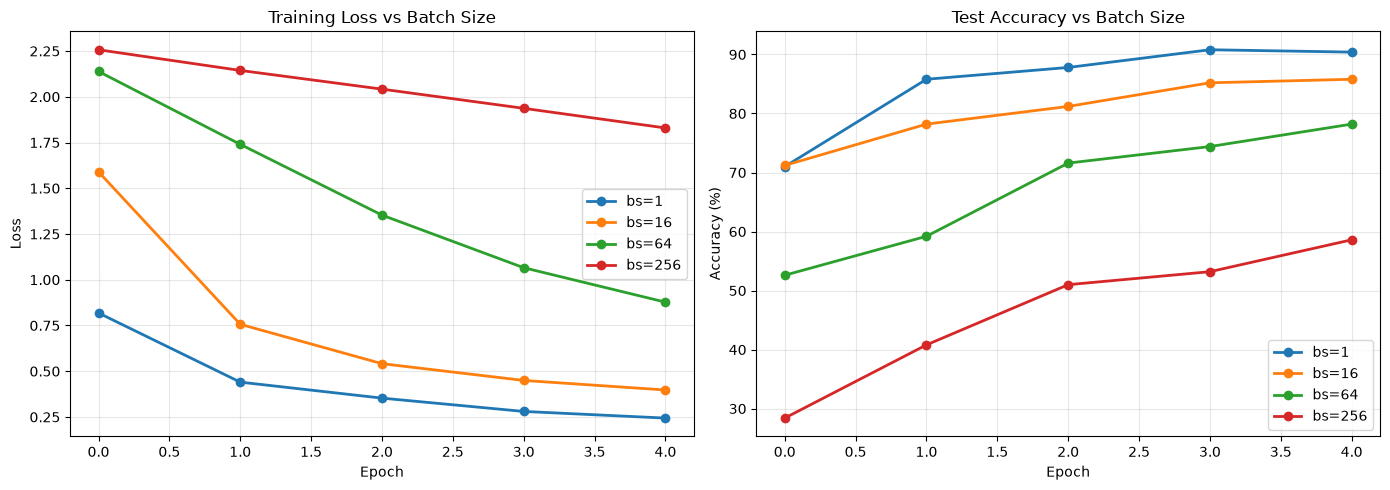


BATCH SIZE INSIGHTS:

• bs = 1:   Very noisy, slow (stochastic gradient descent)
• bs = 16:  Good balance, fast learning
• bs = 64:  Smooth learning, popular choice
• bs = 256: Smoother but slower updates

Best batch size: 64-128 (depends on GPU memory)

Rule of thumb: Start with 64, increase if you have GPU memory



In [5]:
print("\n" + "="*60)
print("EFFECT OF BATCH SIZE")
print("="*60)

def train_with_batch_size(batch_size):
    """Train model with given batch size"""
    model = SimpleMNIST()
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=0.01)
    
    # Create loaders with specified batch size
    train_loader = torch.utils.data.DataLoader(
        torch.utils.data.Subset(train_dataset, range(3000)),
        batch_size=batch_size, shuffle=True
    )
    test_loader = torch.utils.data.DataLoader(
        torch.utils.data.Subset(test_dataset, range(500)),
        batch_size=64, shuffle=False
    )
    
    losses = []
    accuracies = []
    
    for epoch in range(5):
        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        
        avg_loss = running_loss / len(train_loader)
        losses.append(avg_loss)
        
        # Test
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels in test_loader:
                outputs = model(images)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        
        accuracies.append(100 * correct / total)
    
    return losses, accuracies

# Test different batch sizes
batch_sizes = [1, 16, 64, 256]
results_batch = {}

print("Training with different batch sizes...")
for bs in batch_sizes:
    print(f"\n  Batch Size = {bs}")
    train_loss, test_acc = train_with_batch_size(bs)
    results_batch[bs] = {'loss': train_loss, 'accuracy': test_acc}
    print(f"    Final Test Accuracy: {test_acc[-1]:.2f}%")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
ax = axes[0]
for bs, data in results_batch.items():
    ax.plot(data['loss'], label=f'bs={bs}', linewidth=2, marker='o')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Training Loss vs Batch Size')
ax.legend()
ax.grid(True, alpha=0.3)

# Accuracy
ax = axes[1]
for bs, data in results_batch.items():
    ax.plot(data['accuracy'], label=f'bs={bs}', linewidth=2, marker='o')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Test Accuracy vs Batch Size')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("BATCH SIZE INSIGHTS:")
print("="*60)
print("""
• bs = 1:   Very noisy, slow (stochastic gradient descent)
• bs = 16:  Good balance, fast learning
• bs = 64:  Smooth learning, popular choice
• bs = 256: Smoother but slower updates

Best batch size: 64-128 (depends on GPU memory)

Rule of thumb: Start with 64, increase if you have GPU memory
""")


ACTIVATION FUNCTIONS
Training with different activation functions...

  Sigmoid
    Final Test Accuracy: 49.40%

  Tanh
    Final Test Accuracy: 77.80%

  ReLU
    Final Test Accuracy: 77.60%

  Leaky ReLU
    Final Test Accuracy: 78.60%


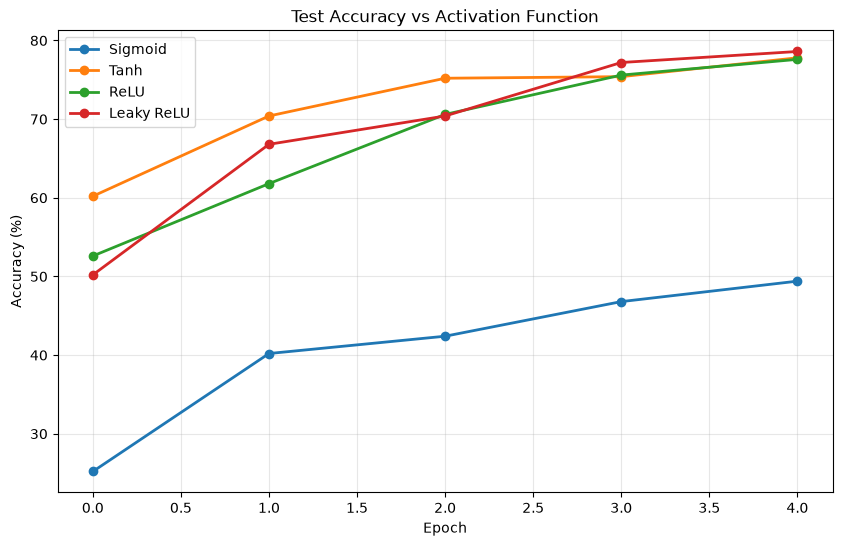


ACTIVATION FUNCTION INSIGHTS:

• Sigmoid:   Vanishing gradient, slow learning
• Tanh:      Better than Sigmoid, but still can vanish
• ReLU:      Fastest, most common (popular choice!)
• Leaky ReLU: Slightly better than ReLU

Best activation: ReLU (or Leaky ReLU)

Rule of thumb: Use ReLU for hidden layers



In [6]:
print("\n" + "="*60)
print("ACTIVATION FUNCTIONS")
print("="*60)

class ActivationTest(nn.Module):
    def __init__(self, activation):
        super(ActivationTest, self).__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28*28, 128)
        self.activation = activation
        self.fc2 = nn.Linear(128, 10)
    
    def forward(self, x):
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.activation(x)
        x = self.fc2(x)
        return x

def train_with_activation(activation_fn, name):
    model = ActivationTest(activation_fn)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=0.01)
    
    train_loader = torch.utils.data.DataLoader(
        torch.utils.data.Subset(train_dataset, range(3000)),
        batch_size=64, shuffle=True
    )
    test_loader = torch.utils.data.DataLoader(
        torch.utils.data.Subset(test_dataset, range(500)),
        batch_size=64, shuffle=False
    )
    
    accuracies = []
    for epoch in range(5):
        model.train()
        for images, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
        
        # Test
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels in test_loader:
                outputs = model(images)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        accuracies.append(100 * correct / total)
    
    return accuracies

# Test different activations
activations = [
    (nn.Sigmoid(), 'Sigmoid'),
    (nn.Tanh(), 'Tanh'),
    (nn.ReLU(), 'ReLU'),
    (nn.LeakyReLU(0.01), 'Leaky ReLU')
]

results_activation = {}
print("Training with different activation functions...")
for activation_fn, name in activations:
    print(f"\n  {name}")
    accuracies = train_with_activation(activation_fn, name)
    results_activation[name] = accuracies
    print(f"    Final Test Accuracy: {accuracies[-1]:.2f}%")

# Visualize
plt.figure(figsize=(10, 6))
for name, accuracies in results_activation.items():
    plt.plot(accuracies, label=name, linewidth=2, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Test Accuracy vs Activation Function')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("\n" + "="*60)
print("ACTIVATION FUNCTION INSIGHTS:")
print("="*60)
print("""
• Sigmoid:   Vanishing gradient, slow learning
• Tanh:      Better than Sigmoid, but still can vanish
• ReLU:      Fastest, most common (popular choice!)
• Leaky ReLU: Slightly better than ReLU

Best activation: ReLU (or Leaky ReLU)

Rule of thumb: Use ReLU for hidden layers
""")


In [8]:
print("\n" + "="*60)
print("PART 5: PRACTICAL TIPS - COMPLETE GUIDE")
print("="*60)


PART 5: PRACTICAL TIPS - COMPLETE GUIDE


#### 1. Learning Rate

| Situation | Action |
|-----------|--------|
| **Start with** | 0.01 |
| **If too slow** | Increase to 0.1 |
| **If unstable** | Decrease to 0.001 |
| **Advanced** | Use learning rate schedulers |


#### 2. Batch Size

| Scenario | Recommendation |
|----------|----------------|
| **Default** | 64–128 |
| **Small batches** | More noise, better generalization |
| **Large batches** | Faster training, may overfit |
| **Limit** | GPU memory |


#### 3. Activation Functions

| Layer Type | Recommended Activation |
|------------|------------------------|
| **Hidden layers** | ReLU (always!) |
| **Output (binary)** | Sigmoid |
| **Output (multi-class)** | Softmax |
| **If dying ReLU problem** | Leaky ReLU or ELU |


#### 4. Optimizers

| Optimizer | Recommendation |
|-----------|----------------|
| **Adam** | Good default (adapts learning rate) |
| **SGD** | Needs tuning, but can be better |
| **Strategy** | Start with Adam, experiment with SGD |


#### 5. Epochs

| Aspect | Recommendation |
|--------|----------------|
| **Start with** | 10–20 |
| **Watch for** | Overfitting |
| **Use** | Early stopping |


#### 6. Overfitting Prevention

| Technique | Typical Value |
|-----------|---------------|
| **Dropout** | 0.2–0.5 |
| **L2 Regularization** | Weight decay |
| **Early stopping** | Monitor validation loss |
| **Data augmentation** | Increase dataset size |


#### 7. Monitoring

| Pattern | Meaning |
|---------|---------|
| **Train loss ↓, Val loss ↑** | Overfitting! |
| **Both flat** | Learning rate too low |
| **Loss explodes** | Learning rate too high |
| **Both decreasing** | ✅ Good progress |